In [ ]:
import torch
import time
import pandas as pd
import numpy as np
from tqdm import tqdm

device = "cuda"

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [ ]:
BATCH_SIZE = 1

sizes = [256, 512, 1024, 2048]

precisions = [
    torch.float32,
    torch.float16
]

WARMUP = 20
ITER = 100
REPEAT = 3

In [ ]:
def gemm_flops(B, N, D):
    return 2 * B * N * (D**2)

def gemm_memory(B, N, D, dtype):
    bytes_per = torch.tensor([], dtype=dtype).element_size()

    input_bytes = B*N*D
    weight_bytes = D*D
    output_bytes = B*N*D

    return bytes_per * (input_bytes + weight_bytes + output_bytes)


def add_flops(B, N, D):
    return B*N*D


def add_memory(B, N, D, dtype):
    bytes_per = torch.tensor([], dtype=dtype).element_size()

    readA = B*N*D
    readB = B*N*D
    write = B*N*D

    return bytes_per * (readA + readB + write)


def softmax_flops(B, N):
    return B * N * 5 * N


def softmax_memory(B, N, dtype):
    bytes_per = torch.tensor([], dtype=dtype).element_size()

    read = B*N*N
    write = B*N*N

    return bytes_per * (read + write)

In [ ]:
def benchmark_kernel(fn):

    # warmup
    for _ in range(WARMUP):
        fn()

    torch.cuda.synchronize()

    times = []

    for _ in range(REPEAT):

        start = time.time()

        for _ in range(ITER):
            fn()

        torch.cuda.synchronize()

        end = time.time()

        times.append((end-start)/ITER*1000)

    return np.mean(times), np.std(times)

In [ ]:
results = []

for precision in precisions:

    for size in sizes:

        B = BATCH_SIZE
        N = size
        D = size

        A = torch.randn(B,N,D, device=device, dtype=precision)
        W = torch.randn(D,D, device=device, dtype=precision)

        def run():
            torch.matmul(A,W)

        latency, std = benchmark_kernel(run)

        flops = gemm_flops(B,N,D)
        mem = gemm_memory(B,N,D,precision)

        OI = flops / mem

        gflops = flops / (latency*1e-3) / 1e9

        results.append({
            "kernel_type":"gemm",
            "precision":str(precision),
            "batch_size":B,
            "hidden_dim":D,
            "seq_len":N,
            "latency_ms":latency,
            "flops":flops,
            "memory_bytes":mem,
            "operational_intensity":OI,
            "achieved_gflops":gflops
        })

In [ ]:
for precision in precisions:

    for size in sizes:

        B = BATCH_SIZE
        N = size
        D = size

        A = torch.randn(B,N,D, device=device, dtype=precision)
        B2 = torch.randn(B,N,D, device=device, dtype=precision)

        def run():
            torch.add(A,B2)

        latency, std = benchmark_kernel(run)

        flops = add_flops(B,N,D)
        mem = add_memory(B,N,D,precision)

        OI = flops / mem

        gflops = flops / (latency*1e-3) / 1e9

        results.append({
            "kernel_type":"add",
            "precision":str(precision),
            "batch_size":B,
            "hidden_dim":D,
            "seq_len":N,
            "latency_ms":latency,
            "flops":flops,
            "memory_bytes":mem,
            "operational_intensity":OI,
            "achieved_gflops":gflops
        })

In [ ]:
for precision in precisions:

    for size in sizes:

        B = BATCH_SIZE
        N = size

        A = torch.randn(B,N,N, device=device, dtype=precision)

        def run():
            torch.softmax(A, dim=-1)

        latency, std = benchmark_kernel(run)

        flops = softmax_flops(B,N)
        mem = softmax_memory(B,N,precision)

        OI = flops / mem

        gflops = flops / (latency*1e-3) / 1e9

        results.append({
            "kernel_type":"softmax",
            "precision":str(precision),
            "batch_size":B,
            "hidden_dim":None,
            "seq_len":N,
            "latency_ms":latency,
            "flops":flops,
            "memory_bytes":mem,
            "operational_intensity":OI,
            "achieved_gflops":gflops
        })

In [ ]:
df = pd.DataFrame(results)

df.to_csv("kernel_benchmark_results.csv", index=False)

df.head()

,kernel_type,precision,batch_size,hidden_dim,seq_len,latency_ms,flops,memory_bytes,operational_intensity,achieved_gflops
0,gemm,torch.float32,1,256.0,256,0.019097,33554432,786432,42.666667,1757.095447
1,gemm,torch.float32,1,512.0,512,0.028768,268435456,3145728,85.333333,9330.919972
2,gemm,torch.float32,1,1024.0,1024,0.197041,2147483648,12582912,170.666667,10898.662054
3,gemm,torch.float32,1,2048.0,2048,1.348828,17179869184,50331648,341.333333,12736.889552
4,gemm,torch.float16,1,256.0,256,0.021188,33554432,393216,85.333333,1583.633266


In [ ]:
def benchmark_kernel(fn, warmup=20, iters=100, repeat=3):
    # warmup
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()

    times = []
    for _ in range(repeat):
        torch.cuda.synchronize()
        start = time.time()

        for _ in range(iters):
            fn()

        torch.cuda.synchronize()
        end = time.time()

        avg_ms = (end - start) / iters * 1000
        times.append(avg_ms)

    return np.mean(times), np.std(times)

In [ ]:
results = []
for precision in precisions:
    for size in sizes:
        B = BATCH_SIZE
        N = size
        D = size

        A = torch.randn(B, N, D, device=device, dtype=precision)
        W = torch.randn(D, D, device=device, dtype=precision)

        def run():
            torch.matmul(A, W)

        latency_mean, latency_std = benchmark_kernel(run, WARMUP, ITER, REPEAT)

        flops = gemm_flops(B, N, D)
        mem = gemm_memory(B, N, D, precision)
        oi = flops / mem
        achieved_gflops = flops / (latency_mean * 1e-3) / 1e9

        results.append({
            "kernel_type": "gemm",
            "precision": str(precision),
            "batch_size": B,
            "hidden_dim": D,
            "seq_len": N,
            "latency_ms": latency_mean,
            "latency_std_ms": latency_std,
            "flops": flops,
            "memory_bytes": mem,
            "operational_intensity": oi,
            "achieved_gflops": achieved_gflops
        })

In [ ]:
for precision in precisions:
    for size in sizes:
        B = BATCH_SIZE
        N = size
        D = size

        A = torch.randn(B, N, D, device=device, dtype=precision)
        B2 = torch.randn(B, N, D, device=device, dtype=precision)

        def run():
            torch.add(A, B2)

        latency_mean, latency_std = benchmark_kernel(run, WARMUP, ITER, REPEAT)

        flops = add_flops(B, N, D)
        mem = add_memory(B, N, D, precision)
        oi = flops / mem
        achieved_gflops = flops / (latency_mean * 1e-3) / 1e9

        results.append({
            "kernel_type": "add",
            "precision": str(precision),
            "batch_size": B,
            "hidden_dim": D,
            "seq_len": N,
            "latency_ms": latency_mean,
            "latency_std_ms": latency_std,
            "flops": flops,
            "memory_bytes": mem,
            "operational_intensity": oi,
            "achieved_gflops": achieved_gflops
        })

In [ ]:
for precision in precisions:
    for size in sizes:
        B = BATCH_SIZE
        N = size

        A = torch.randn(B, N, N, device=device, dtype=precision)

        def run():
            torch.softmax(A, dim=-1)

        latency_mean, latency_std = benchmark_kernel(run, WARMUP, ITER, REPEAT)

        flops = softmax_flops(B, N)
        mem = softmax_memory(B, N, precision)
        oi = flops / mem
        achieved_gflops = flops / (latency_mean * 1e-3) / 1e9

        results.append({
            "kernel_type": "softmax",
            "precision": str(precision),
            "batch_size": B,
            "hidden_dim": None,
            "seq_len": N,
            "latency_ms": latency_mean,
            "latency_std_ms": latency_std,
            "flops": flops,
            "memory_bytes": mem,
            "operational_intensity": oi,
            "achieved_gflops": achieved_gflops
        })

In [ ]:
df = pd.DataFrame(results)
df

,kernel_type,precision,batch_size,hidden_dim,seq_len,latency_ms,latency_std_ms,flops,memory_bytes,operational_intensity,achieved_gflops
0,gemm,torch.float32,1,256.0,256,0.018663,0.000080,33554432,786432,42.666667,1797.872871
1,gemm,torch.float32,1,512.0,512,0.028876,0.000045,268435456,3145728,85.333333,9295.994827
2,gemm,torch.float32,1,1024.0,1024,0.208537,0.023791,2147483648,12582912,170.666667,10297.865002
3,gemm,torch.float32,1,2048.0,2048,1.361383,0.008335,17179869184,50331648,341.333333,12619.425745
4,gemm,torch.float16,1,256.0,256,0.021014,0.000169,33554432,393216,85.333333,1596.749357
5,gemm,torch.float16,1,512.0,512,0.019081,0.000080,268435456,1572864,170.666667,14068.473158
6,gemm,torch.float16,1,1024.0,1024,0.051271,0.001672,2147483648,6291456,341.333333,41884.858735
7,gemm,torch.float16,1,2048.0,2048,0.331376,0.029499,17179869184,25165824,682.666667,51843.974145
8,add,torch.float32,1,256.0,256,0.009576,0.000048,65536,786432,0.083333,6.843433
9,add,torch.float32,1,512.0,512,0.009480,0.000099,262144,3145728,0.083333,27.651395


In [ ]:
df.to_csv("kernel_benchmark_results.csv", index=False)
print("Saved to kernel_benchmark_results.csv")

Saved to kernel_benchmark_results.csv


In [ ]:
df.groupby(["kernel_type", "precision"]).size()

kernel_type  precision    
add          torch.float16    4
             torch.float32    4
gemm         torch.float16    4
             torch.float32    4
softmax      torch.float16    4
             torch.float32    4
dtype: int64

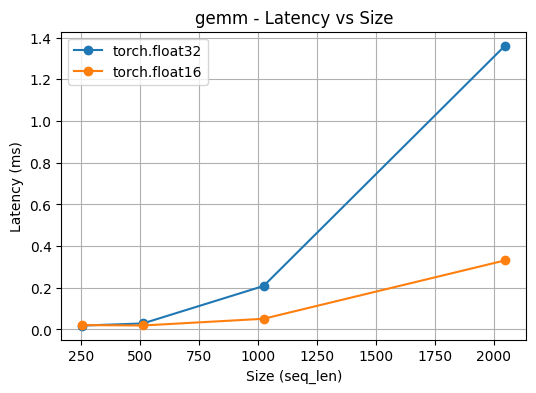

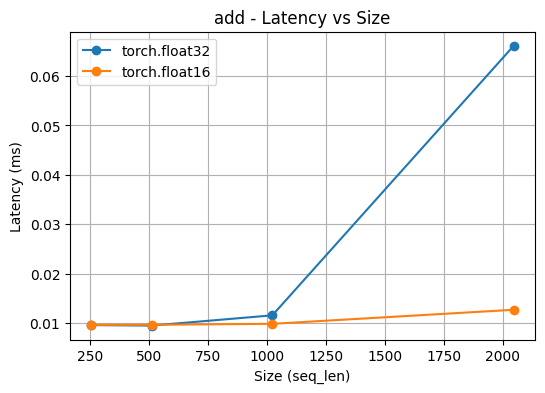

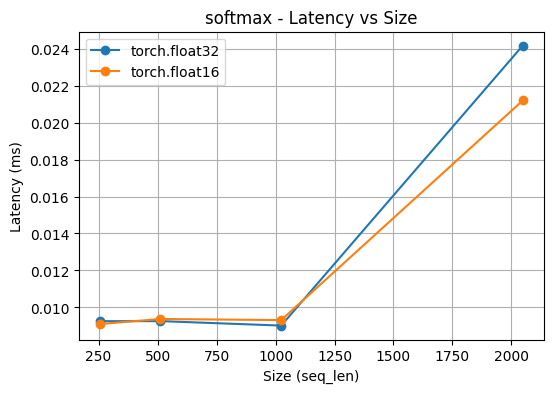

In [ ]:
import matplotlib.pyplot as plt

for kernel in df["kernel_type"].unique():
    sub = df[df["kernel_type"] == kernel]

    plt.figure(figsize=(6,4))
    for precision in sub["precision"].unique():
        s = sub[sub["precision"] == precision].sort_values("seq_len")
        plt.plot(s["seq_len"], s["latency_ms"], marker="o", label=precision)

    plt.xlabel("Size (seq_len)")
    plt.ylabel("Latency (ms)")
    plt.title(f"{kernel} - Latency vs Size")
    plt.legend()
    plt.grid(True)
    plt.show()

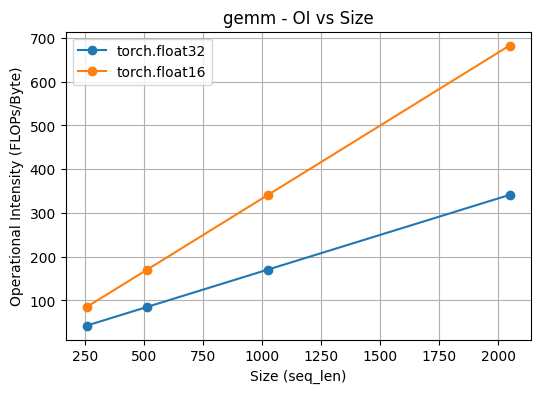

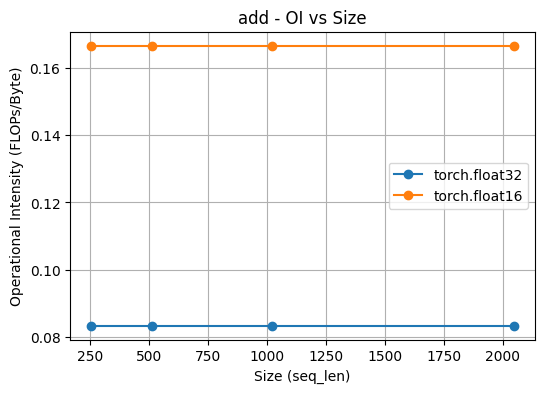

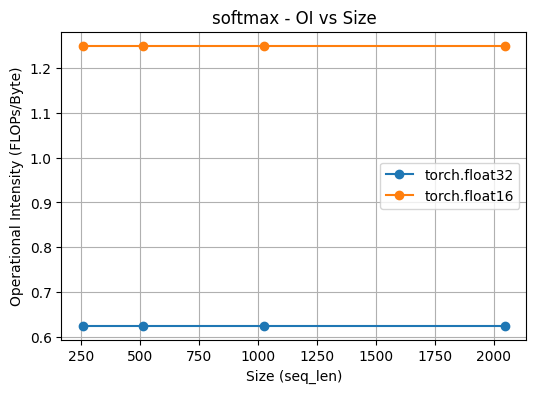

In [ ]:
for kernel in df["kernel_type"].unique():
    sub = df[df["kernel_type"] == kernel]

    plt.figure(figsize=(6,4))
    for precision in sub["precision"].unique():
        s = sub[sub["precision"] == precision].sort_values("seq_len")
        plt.plot(s["seq_len"], s["operational_intensity"], marker="o", label=precision)

    plt.xlabel("Size (seq_len)")
    plt.ylabel("Operational Intensity (FLOPs/Byte)")
    plt.title(f"{kernel} - OI vs Size")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
df.groupby(["kernel_type","precision"]).size()

kernel_type  precision    
add          torch.float16    4
             torch.float32    4
gemm         torch.float16    4
             torch.float32    4
softmax      torch.float16    4
             torch.float32    4
dtype: int64

In [ ]:
df.to_csv("kernel_benchmark_results.csv", index=False)

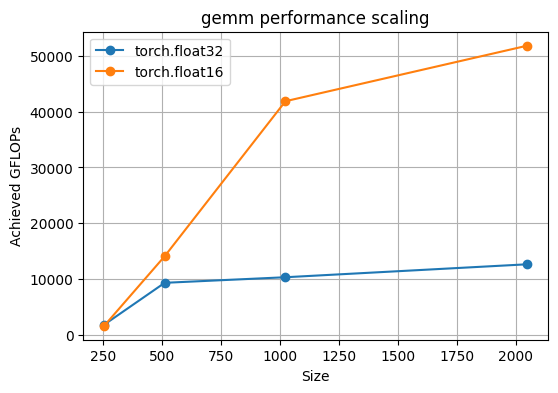

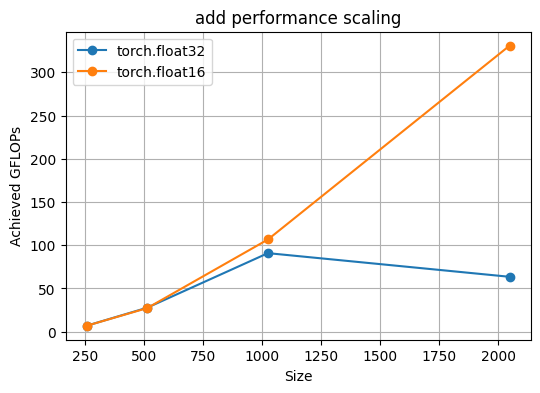

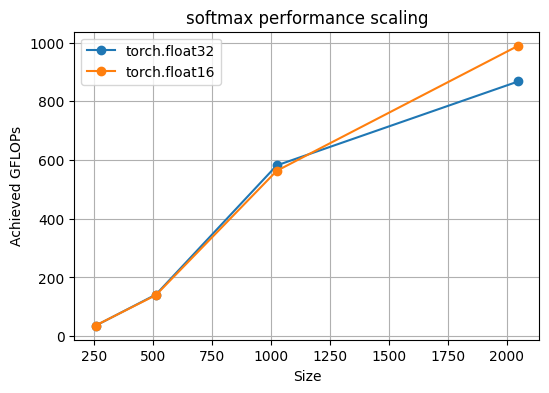

In [ ]:
for kernel in df["kernel_type"].unique():
    sub = df[df["kernel_type"] == kernel]

    plt.figure(figsize=(6,4))

    for precision in sub["precision"].unique():
        s = sub[sub["precision"] == precision].sort_values("seq_len")

        plt.plot(
            s["seq_len"],
            s["achieved_gflops"],
            marker="o",
            label=precision
        )

    plt.xlabel("Size")
    plt.ylabel("Achieved GFLOPs")
    plt.title(f"{kernel} performance scaling")
    plt.legend()
    plt.grid(True)
    plt.show()

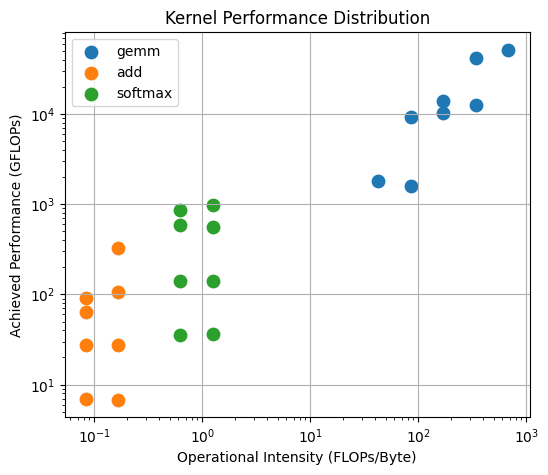

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

for kernel in df["kernel_type"].unique():
    sub = df[df["kernel_type"] == kernel]

    plt.scatter(
        sub["operational_intensity"],
        sub["achieved_gflops"],
        label=kernel,
        s=80
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Operational Intensity (FLOPs/Byte)")
plt.ylabel("Achieved Performance (GFLOPs)")
plt.title("Kernel Performance Distribution")

plt.legend()
plt.grid(True)
plt.show()

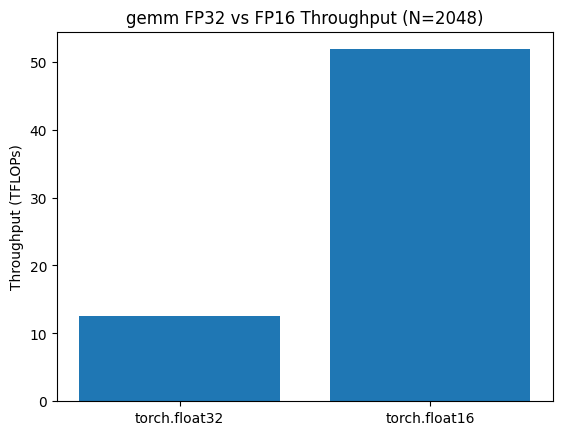

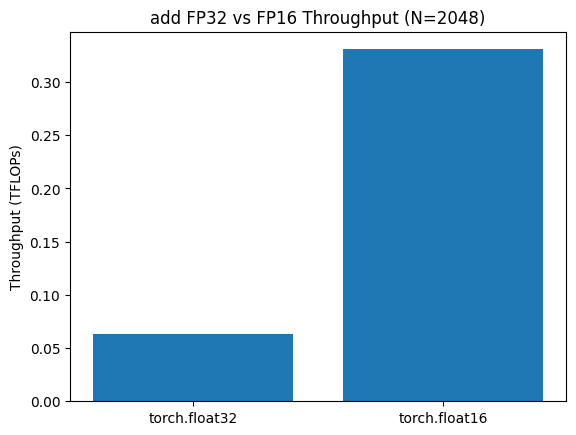

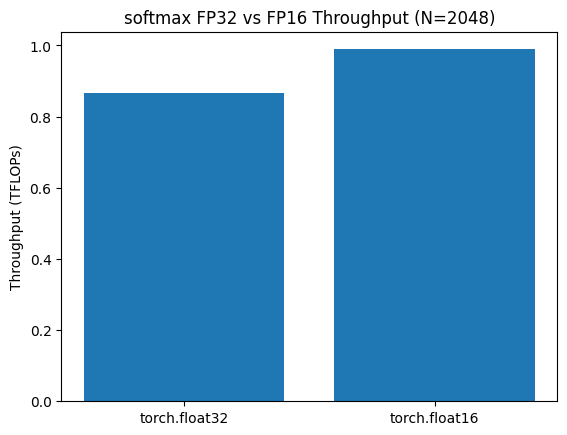

In [ ]:
size = 2048

sub = df[df["seq_len"] == size]

import matplotlib.pyplot as plt

for kernel in sub["kernel_type"].unique():

    s = sub[sub["kernel_type"] == kernel]

    plt.figure()

    plt.bar(
        s["precision"],
        s["achieved_gflops"]/1000
    )

    plt.ylabel("Throughput (TFLOPs)")
    plt.title(f"{kernel} FP32 vs FP16 Throughput (N={size})")

    plt.show()

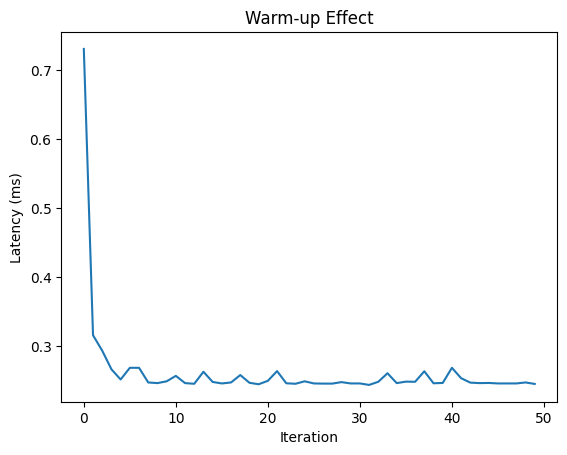

In [ ]:
times = []

for i in range(50):

    torch.cuda.synchronize()
    start = time.time()

    torch.matmul(A, W)

    torch.cuda.synchronize()
    end = time.time()

    times.append((end-start)*1000)
plt.plot(times)
plt.xlabel("Iteration")
plt.ylabel("Latency (ms)")
plt.title("Warm-up Effect")
plt.show()

In [ ]:
speedup_df = df.pivot_table(
    index=["kernel_type", "seq_len"],
    columns="precision",
    values="achieved_gflops"
).reset_index()

speedup_df["fp16_speedup"] = (
    speedup_df["torch.float16"] / speedup_df["torch.float32"]
)

speedup_df

precision,kernel_type,seq_len,torch.float16,torch.float32,fp16_speedup
0,add,256,6.811777,6.843433,0.995374
1,add,512,27.193198,27.651395,0.983430
2,add,1024,106.602081,90.781199,1.174275
3,add,2048,330.763087,63.423453,5.215154
4,gemm,256,1596.749357,1797.872871,0.888133
5,gemm,512,14068.473158,9295.994827,1.513391
6,gemm,1024,41884.858735,10297.865002,4.067334
7,gemm,2048,51843.974145,12619.425745,4.108267
8,softmax,256,36.007061,35.410242,1.016854
9,softmax,512,139.851390,141.592328,0.987705
